In [1]:
path = r'\\NAS3_Z\all\BKP_PERE\BBDD_Datasets\TEST_DICOM\2024\01\2\310743'

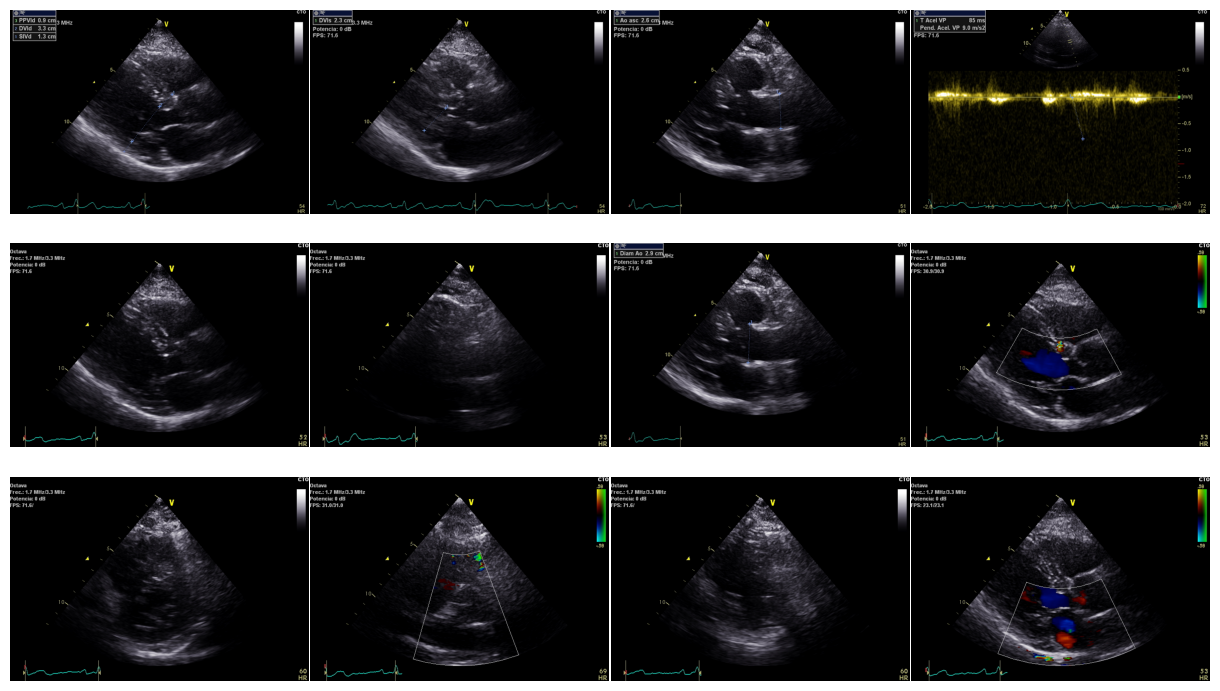

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pydicom
from pydicom.pixel_data_handlers.util import convert_color_space


def get_first_frame(ds):
    pixels = ds.pixel_array
    photometric = ds.PhotometricInterpretation
    is_color = photometric not in {"MONOCHROME1", "MONOCHROME2"}

    if is_color:
        frame = pixels[0] if pixels.ndim == 4 else pixels
        if photometric != "RGB":
            try:
                frame = convert_color_space(frame, photometric, "RGB")
            except ValueError:
                pass
        return frame, None

    frame = pixels[0] if pixels.ndim == 3 else pixels
    if photometric == "MONOCHROME1":
        frame = frame.max() - frame
    return frame, "gray"


wado_files = sorted(
    file for file in Path(path).rglob("*")
    if file.is_file() and file.name.upper().startswith("WADO")
)[:12]

fig, axes = plt.subplots(3, 4, figsize=(12, 7))
for ax, dicom_path in zip(axes.flat, wado_files):
    ds = pydicom.dcmread(dicom_path)
    frame, cmap = get_first_frame(ds)
    ax.imshow(frame, cmap=cmap)
    ax.axis("off")

for ax in axes.flat[len(wado_files):]:
    ax.axis("off")

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.005, hspace=0.005)
plt.show()

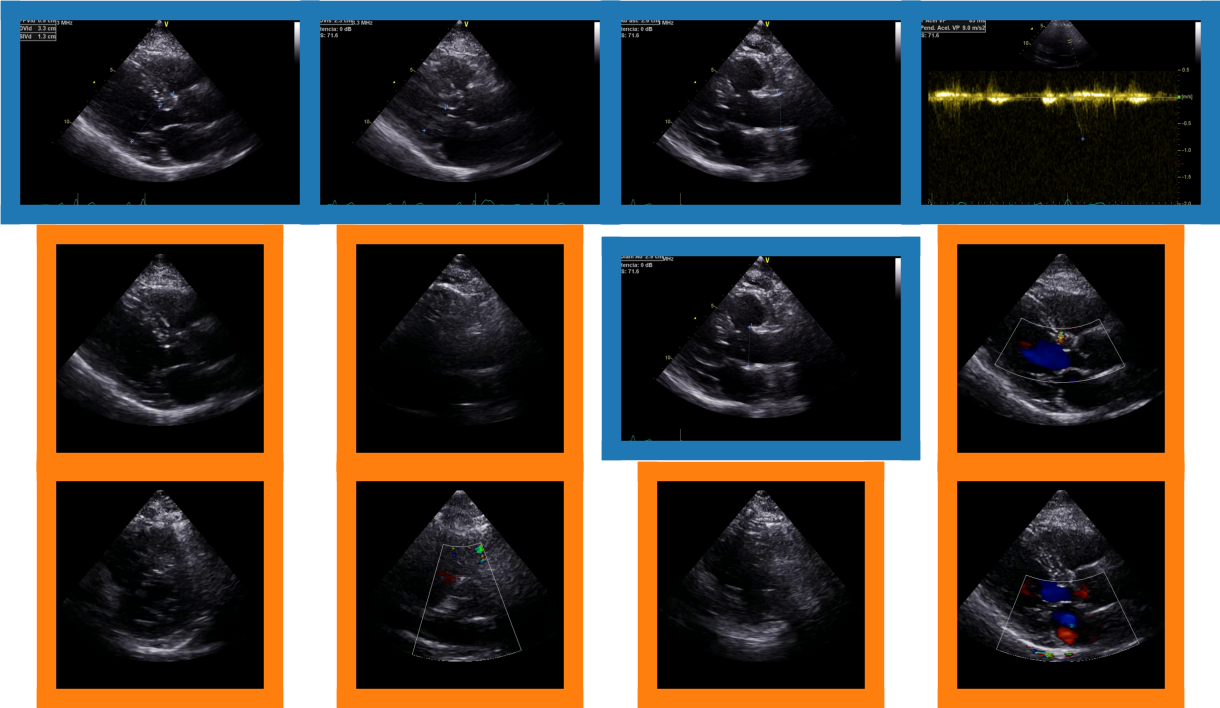

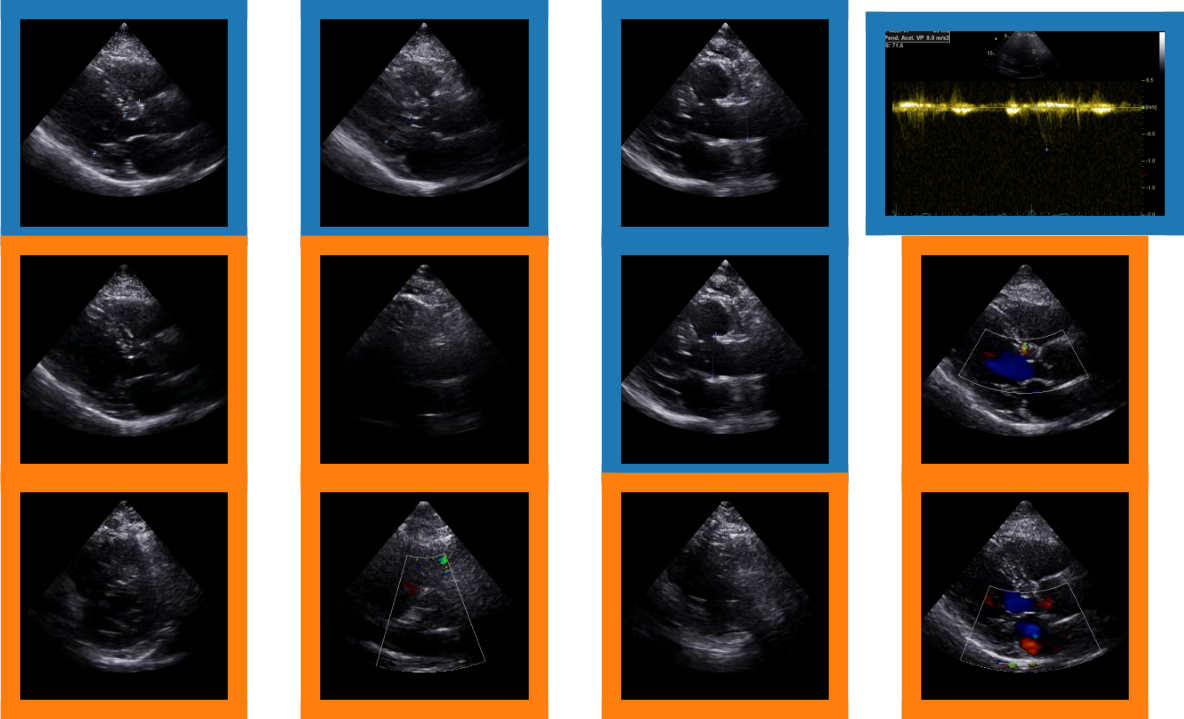

In [9]:
import cv2

cropped_path = Path(r"\\NAS3_Z\all\BKP_PERE\BBDD_Datasets\TEST_AVI3\vids_cropped\2024\01\2\310743")
resized_path = Path(r"\\NAS3_Z\all\BKP_PERE\BBDD_Datasets\TEST_AVI3\vids_resized\2024\01\2\310743")


def index_outputs(folder):
    return {
        file.stem.upper(): file
        for file in folder.rglob("*")
        if file.is_file() and file.suffix.lower() in {".png", ".avi"}
    }


def read_output(file_path):
    if file_path.suffix.lower() == ".png":
        image = cv2.imread(str(file_path), cv2.IMREAD_UNCHANGED)
        if image is None:
            raise ValueError(f"Could not read {file_path}")
        if image.ndim == 3:
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        return image

    capture = cv2.VideoCapture(str(file_path))
    success, frame = capture.read()
    capture.release()
    if not success:
        raise ValueError(f"Could not read the first frame of {file_path}")
    return cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)


def plot_output_grid(folder):
    output_index = index_outputs(folder)
    fig, axes = plt.subplots(3, 4, figsize=(12, 7))

    for ax, dicom_path in zip(axes.flat, wado_files):
        output_path = output_index.get(dicom_path.stem.upper())
        if output_path is None:
            ax.axis("off")
            continue

        image = read_output(output_path)
        ax.imshow(image, cmap="gray" if image.ndim == 2 else None)
        ax.set_xticks([])
        ax.set_yticks([])
        border_color = "tab:blue" if output_path.suffix.lower() == ".png" else "tab:orange"
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_color(border_color)
            spine.set_linewidth(14)

    for ax in axes.flat[len(wado_files):]:
        ax.axis("off")

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.005, hspace=0.04)
    plt.show()


plot_output_grid(cropped_path)
plot_output_grid(resized_path)